In [2]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=e207d9c979860566210beec054c14cf1ec60d3f45abfc0a0bcf807a924d67b4e
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [3]:
# step1_load_dataset.py
# Downloads LFW dataset automatically (no manual Kaggle download needed)
# and exports images into person-named folders, like a real dataset structure

from sklearn.datasets import fetch_lfw_people
import numpy as np
import cv2
import os

# min_faces_per_person=20 keeps only people with at least 20 photos
# (LFW has many people with just 1 photo - useless for training)
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)

images = lfw.images        # shape: (n_samples, height, width, 3), pixel values 0-1
labels = lfw.target        # numeric label per image
target_names = lfw.target_names  # actual person names

print(f"Loaded {len(images)} images across {len(target_names)} people")
print("People included:", list(target_names))

# To keep this manageable for a student project, let's use only 5 people
# (pick the 5 with the most photos for reliable training)
unique, counts = np.unique(labels, return_counts=True)
top5_ids = unique[np.argsort(-counts)][:5]

dataset_path = "dataset"
os.makedirs(dataset_path, exist_ok=True)

for person_id in top5_ids:
    person_name = target_names[person_id].replace(" ", "_")
    person_folder = os.path.join(dataset_path, person_name)
    os.makedirs(person_folder, exist_ok=True)

    person_images = images[labels == person_id]

    for i, img in enumerate(person_images):
        img_uint8 = (img * 255).astype(np.uint8)          # convert float [0,1] to uint8 [0,255]
        img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)  # cv2 expects BGR, not RGB
        cv2.imwrite(f"{person_folder}/img_{i}.jpg", img_bgr)

    print(f"Saved {len(person_images)} images for {person_name}")

print("\nDataset folder ready at ./dataset/")

Loaded 3023 images across 62 people
People included: [np.str_('Alejandro Toledo'), np.str_('Alvaro Uribe'), np.str_('Amelie Mauresmo'), np.str_('Andre Agassi'), np.str_('Angelina Jolie'), np.str_('Ariel Sharon'), np.str_('Arnold Schwarzenegger'), np.str_('Atal Bihari Vajpayee'), np.str_('Bill Clinton'), np.str_('Carlos Menem'), np.str_('Colin Powell'), np.str_('David Beckham'), np.str_('Donald Rumsfeld'), np.str_('George Robertson'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Gloria Macapagal Arroyo'), np.str_('Gray Davis'), np.str_('Guillermo Coria'), np.str_('Hamid Karzai'), np.str_('Hans Blix'), np.str_('Hugo Chavez'), np.str_('Igor Ivanov'), np.str_('Jack Straw'), np.str_('Jacques Chirac'), np.str_('Jean Chretien'), np.str_('Jennifer Aniston'), np.str_('Jennifer Capriati'), np.str_('Jennifer Lopez'), np.str_('Jeremy Greenstock'), np.str_('Jiang Zemin'), np.str_('John Ashcroft'), np.str_('John Negroponte'), np.str_('Jose Maria Aznar'), np.str_('Juan Carlos Ferr

In [4]:
# step2_train_test_split.py
# Splits each person's folder into training images and held-out test images

import os
import shutil
import random

dataset_path = "dataset"
train_path = "dataset_train"
test_path = "dataset_test"

os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

random.seed(42)

for person_name in os.listdir(dataset_path):
    person_folder = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_folder):
        continue

    images = os.listdir(person_folder)
    random.shuffle(images)

    split_index = int(len(images) * 0.8)   # 80% train, 20% test
    train_images = images[:split_index]
    test_images = images[split_index:]

    os.makedirs(f"{train_path}/{person_name}", exist_ok=True)
    os.makedirs(f"{test_path}/{person_name}", exist_ok=True)

    for img in train_images:
        shutil.copy(f"{person_folder}/{img}", f"{train_path}/{person_name}/{img}")
    for img in test_images:
        shutil.copy(f"{person_folder}/{img}", f"{test_path}/{person_name}/{img}")

    print(f"{person_name}: {len(train_images)} train, {len(test_images)} test")

Donald_Rumsfeld: 96 train, 25 test
Tony_Blair: 115 train, 29 test
Colin_Powell: 188 train, 48 test
Gerhard_Schroeder: 87 train, 22 test
George_W_Bush: 424 train, 106 test


In [5]:
# step3_train_encodings.py

import face_recognition
import os
import pickle

dataset_path = "dataset_train"
known_encodings = []
known_names = []

for person_name in os.listdir(dataset_path):
    person_folder = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_folder):
        continue

    for image_name in os.listdir(person_folder):
        image_path = os.path.join(person_folder, image_name)
        image = face_recognition.load_image_file(image_path)

        face_locations = face_recognition.face_locations(image, model="hog")
        if len(face_locations) == 0:
            print(f"No face found in {image_path}, skipping.")
            continue

        encoding = face_recognition.face_encodings(image, face_locations)[0]
        known_encodings.append(encoding)
        known_names.append(person_name)

data = {"encodings": known_encodings, "names": known_names}
with open("face_encodings.pkl", "wb") as f:
    pickle.dump(data, f)

print(f"Encoded {len(known_encodings)} training images for {len(set(known_names))} people.")

No face found in dataset_train/Donald_Rumsfeld/img_1.jpg, skipping.
No face found in dataset_train/Donald_Rumsfeld/img_83.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_8.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_41.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_99.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_18.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_57.jpg, skipping.
No face found in dataset_train/Tony_Blair/img_32.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_46.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_219.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_88.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_160.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_191.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_113.jpg, skipping.
No face found in dataset_train/Colin_Powell/img_44.jpg, skipping.
No face found 

In [6]:
# step4_train_classifier.py

import pickle
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

with open("face_encodings.pkl", "rb") as f:
    data = pickle.load(f)

X = data["encodings"]
y = data["names"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

clf = SVC(kernel='linear', probability=True)
clf.fit(X, y_encoded)

with open("svm_classifier.pkl", "wb") as f:
    pickle.dump({"model": clf, "label_encoder": le}, f)

print("SVM trained. Classes:", list(le.classes_))

SVM trained. Classes: [np.str_('Colin_Powell'), np.str_('Donald_Rumsfeld'), np.str_('George_W_Bush'), np.str_('Gerhard_Schroeder'), np.str_('Tony_Blair')]


In [7]:
# step5_evaluate.py

import face_recognition
import os
import pickle
from sklearn.metrics import accuracy_score, classification_report

with open("svm_classifier.pkl", "rb") as f:
    clf_data = pickle.load(f)
clf = clf_data["model"]
le = clf_data["label_encoder"]

test_path = "dataset_test"
true_labels = []
predicted_labels = []

for person_name in os.listdir(test_path):
    person_folder = os.path.join(test_path, person_name)
    if not os.path.isdir(person_folder):
        continue

    for image_name in os.listdir(person_folder):
        image_path = os.path.join(person_folder, image_name)
        image = face_recognition.load_image_file(image_path)

        face_locations = face_recognition.face_locations(image, model="hog")
        if len(face_locations) == 0:
            continue

        encoding = face_recognition.face_encodings(image, face_locations)[0]
        pred = clf.predict([encoding])[0]
        predicted_name = le.inverse_transform([pred])[0]

        true_labels.append(person_name)
        predicted_labels.append(predicted_name)

acc = accuracy_score(true_labels, predicted_labels)
print(f"Test Accuracy: {acc*100:.2f}%\n")
print(classification_report(true_labels, predicted_labels))

Test Accuracy: 100.00%

                   precision    recall  f1-score   support

     Colin_Powell       1.00      1.00      1.00        44
  Donald_Rumsfeld       1.00      1.00      1.00        23
    George_W_Bush       1.00      1.00      1.00        99
Gerhard_Schroeder       1.00      1.00      1.00        21
       Tony_Blair       1.00      1.00      1.00        28

         accuracy                           1.00       215
        macro avg       1.00      1.00      1.00       215
     weighted avg       1.00      1.00      1.00       215



In [8]:
# step6_simulate_attendance.py

import face_recognition
import os
import pickle
import pandas as pd
from datetime import datetime
import time

with open("svm_classifier.pkl", "rb") as f:
    clf_data = pickle.load(f)
clf = clf_data["model"]
le = clf_data["label_encoder"]

attendance_file = "attendance.csv"
if not os.path.exists(attendance_file):
    pd.DataFrame(columns=["Name", "Date", "Time", "Confidence"]).to_csv(attendance_file, index=False)

def mark_attendance(name, confidence):
    df = pd.read_csv(attendance_file)
    today = datetime.now().strftime("%Y-%m-%d")
    already_marked = ((df["Name"] == name) & (df["Date"] == today)).any()

    if not already_marked:
        now = datetime.now().strftime("%H:%M:%S")
        new_entry = pd.DataFrame([[name, today, now, round(confidence, 2)]],
                                  columns=["Name", "Date", "Time", "Confidence"])
        df = pd.concat([df, new_entry], ignore_index=True)
        df.to_csv(attendance_file, index=False)
        print(f"Marked attendance: {name} ({confidence*100:.1f}% confidence) at {now}")

test_path = "dataset_test"
CONFIDENCE_THRESHOLD = 0.5

print("Simulating camera feed using test images...\n")

for person_name in os.listdir(test_path):
    person_folder = os.path.join(test_path, person_name)
    if not os.path.isdir(person_folder):
        continue

    # Just use the first test image per person, like one "camera snapshot" per person
    image_name = os.listdir(person_folder)[0]
    image_path = os.path.join(person_folder, image_name)
    image = face_recognition.load_image_file(image_path)

    face_locations = face_recognition.face_locations(image, model="hog")
    if len(face_locations) == 0:
        continue

    encoding = face_recognition.face_encodings(image, face_locations)[0]
    probabilities = clf.predict_proba([encoding])[0]
    best_index = probabilities.argmax()
    confidence = probabilities[best_index]

    if confidence > CONFIDENCE_THRESHOLD:
        predicted_name = le.inverse_transform([best_index])[0]
        mark_attendance(predicted_name, confidence)
    else:
        print(f"Face in {image_path} not confidently recognized (treated as Unknown).")

    time.sleep(1)  # just to simulate "one person at a time" arriving

print("\nSimulation complete. Check attendance.csv for the log.")

Simulating camera feed using test images...

Marked attendance: Donald_Rumsfeld (97.2% confidence) at 14:29:44


/tmp/ipykernel_2211/3289969534.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_entry], ignore_index=True)


Marked attendance: Tony_Blair (97.7% confidence) at 14:29:45
Marked attendance: Colin_Powell (97.6% confidence) at 14:29:46
Marked attendance: Gerhard_Schroeder (96.6% confidence) at 14:29:47
Marked attendance: George_W_Bush (99.9% confidence) at 14:29:48

Simulation complete. Check attendance.csv for the log.


In [9]:
import pandas as pd
df = pd.read_csv("attendance.csv")
print(df)

                Name        Date      Time  Confidence
0    Donald_Rumsfeld  2026-07-13  14:29:44        0.97
1         Tony_Blair  2026-07-13  14:29:45        0.98
2       Colin_Powell  2026-07-13  14:29:46        0.98
3  Gerhard_Schroeder  2026-07-13  14:29:47        0.97
4      George_W_Bush  2026-07-13  14:29:48        1.00


,Name,Date,Time,Confidence
0,Donald_Rumsfeld,2026-07-13,14:29:44,0.97
1,Tony_Blair,2026-07-13,14:29:45,0.98
2,Colin_Powell,2026-07-13,14:29:46,0.98
3,Gerhard_Schroeder,2026-07-13,14:29:47,0.97
4,George_W_Bush,2026-07-13,14:29:48,1.00


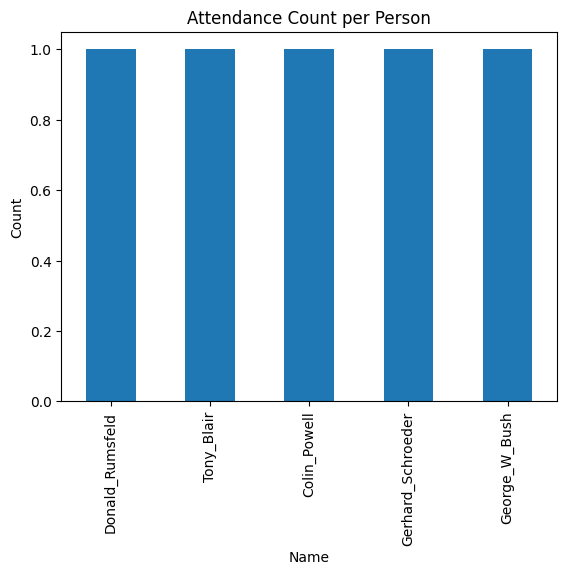

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("attendance.csv")
display(df)   # renders as a nice table in Colab

df['Name'].value_counts().plot(kind='bar', title='Attendance Count per Person')
plt.ylabel("Count")
plt.show()

In [11]:
from google.colab import files

files.download('face_encodings.pkl')
files.download('svm_classifier.pkl')
files.download('attendance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>